# Harmonic Oscillator

## What Is It?
A harmonic oscillator models any system that oscillates
around an equilibrium — like a spring, pendulum, or LC circuit.

## The ODE System
`dy1/dt = y2`
`dy2/dt = -y1`

Where y1 = position, y2 = velocity

**Exact solution:** y1(t) = cos(t), y2(t) = -sin(t)

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'python'))
sys.path.insert(0, os.path.join('..', 'build'))
import numpy as np
import matplotlib.pyplot as plt
from fastode_interface import solve

In [2]:
def harmonic(t, y):
    return [y[1], -y[0]]

result = solve(harmonic, t0=0, t1=4*np.pi,
               y0=[1.0, 0.0], method='RK45')
t_exact = np.linspace(0, 4*np.pi, 500)
y1_exact = np.cos(t_exact)
y2_exact = -np.sin(t_exact)

print(f'Steps: {result.n_steps}, Rejected: {result.n_rejected}')

Steps: 62, Rejected: 12


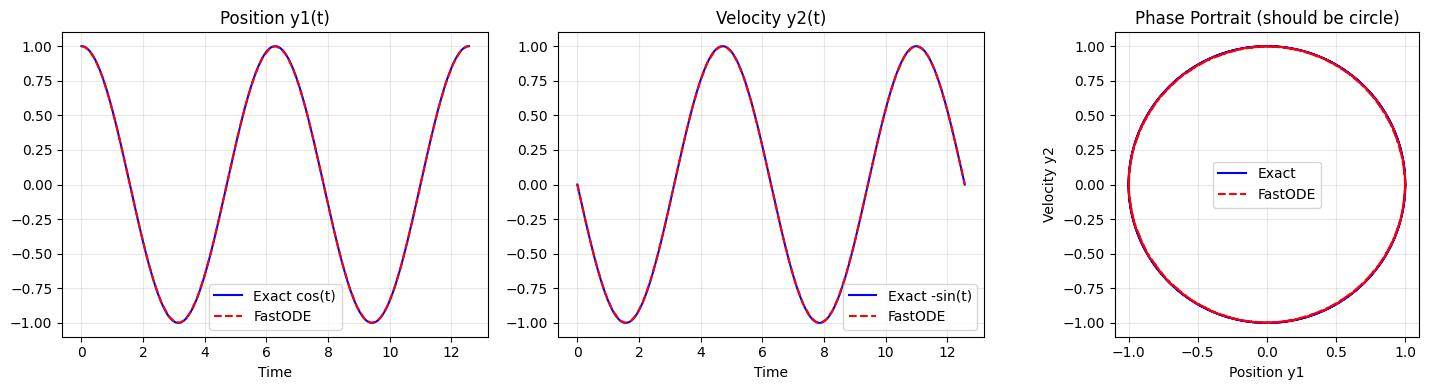

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(t_exact, y1_exact, 'b-', label='Exact cos(t)')
axes[0].plot(result.t, result.y[0], 'r--', label='FastODE')
axes[0].set_title('Position y1(t)')
axes[0].set_xlabel('Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_exact, y2_exact, 'b-', label='Exact -sin(t)')
axes[1].plot(result.t, result.y[1], 'r--', label='FastODE')
axes[1].set_title('Velocity y2(t)')
axes[1].set_xlabel('Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(y1_exact, y2_exact, 'b-', label='Exact')
axes[2].plot(result.y[0], result.y[1], 'r--', label='FastODE')
axes[2].set_xlabel('Position y1')
axes[2].set_ylabel('Velocity y2')
axes[2].set_title('Phase Portrait (should be circle)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_aspect('equal')

plt.tight_layout()
plt.savefig('harmonic_oscillator.png', dpi=100)
plt.show()